# Facebook Ads Performance Analysis

**Which campaigns turn ad spend into value, and where should the budget go next?**

This notebook analyses daily performance data from 11 Facebook ad campaigns (November 2020 to November 2022): spend, impressions, clicks and the value generated. The goal is to compare campaign efficiency, see how spend and returns changed over time, and turn the numbers into practical budget recommendations.

**Tools:** Python, pandas, matplotlib, seaborn

### Metrics

| Metric | Definition | How to read it |
|---|---|---|
| **ROMI** | `total_value / total_spend` | Value returned per 1 unit of spend. **1.0 = break-even**, above 1.0 = profitable |
| **CPC** | cost per click | Lower = cheaper traffic |
| **CPM** | cost per 1,000 impressions | Price of reach |
| **CTR** | clicks / impressions | How engaging the ad is |

### Questions

1. How did ad spend and ROMI change over time?
2. Which campaigns return the most per unit of spend, and where does most of the budget go?
3. How stable is ROMI from day to day?
4. How are spend, reach and returns related?

## Key findings

- **The account is profitable overall:** about 195.8K spent and 247.2K returned, a total **ROMI of 1.26**.
- **Two campaigns clearly outperform:** *Trendy* (ROMI 1.91) and *Promos* (1.76). The other nine campaigns sit in a narrow 1.19 to 1.27 range.
- **Most of the budget goes to average performers:** *Expansion* and *Lookalike* take about **67% of all spend** at a ROMI of roughly 1.25, while *Trendy* and *Promos* together get only **3.6%**.
- **Higher spend did not reduce efficiency:** daily spend grew from almost zero in early 2021 to a summer peak, while daily ROMI stayed in the same range. Spend and ROMI are almost uncorrelated (-0.11).
- **Value follows spend almost one-to-one** (correlation 0.98), so what matters most is *where* the money goes.

## 1. Libraries and data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

NAVY = "#3E5C8A"
ROSE = "#D9958F"
sns.set_theme(style="whitegrid")

In [2]:
url = "https://drive.google.com/uc?export=download&id=12JrQfy3_pszlKbSkLrln1T63Ec3hD7tt"

df = pd.read_csv(url)
df.head(10)

,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
0,2022-11-05,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
1,2022-11-01,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
2,2022-10-31,Expansion,227.45,6054,58,191.87,3.92,37.57,0.009580,0.843570
3,2022-10-30,Expansion,335.91,27562,69,472.61,4.87,12.19,0.002503,1.406954
4,2022-10-29,Expansion,714.03,33358,115,680.34,6.21,21.41,0.003447,0.952817
5,2022-10-28,Expansion,630.33,5522,121,590.00,5.21,114.15,0.021912,0.936018
6,2022-10-27,Expansion,359.63,45223,87,376.69,4.13,7.95,0.001924,1.047438
7,2022-07-11,Expansion,33.02,2674,40,47.02,0.83,12.35,0.014959,1.423985
8,2022-07-10,Expansion,234.34,11266,74,254.62,3.17,20.80,0.006568,1.086541
9,2022-07-09,Expansion,461.70,25300,53,355.11,8.71,18.25,0.002095,0.769136


Each row is one campaign on one day. A quick check of the structure and data quality before the analysis:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ad_date            1494 non-null   object 
 1   campaign_name      1494 non-null   object 
 2   total_spend        1494 non-null   float64
 3   total_impressions  1494 non-null   int64  
 4   total_clicks       1494 non-null   int64  
 5   total_value        1494 non-null   float64
 6   cpc                1443 non-null   float64
 7   cpm                1462 non-null   float64
 8   ctr                1462 non-null   float64
 9   romi               1462 non-null   float64
dtypes: float64(6), int64(2), object(2)
memory usage: 116.8+ KB


In [4]:
print("Duplicate rows:", df.duplicated().sum())
print("Rows with zero spend:", (df['total_spend'] == 0).sum())
df.isna().sum()

Duplicate rows: 0
Rows with zero spend: 32


ad_date               0
campaign_name         0
total_spend           0
total_impressions     0
total_clicks          0
total_value           0
cpc                  51
cpm                  32
ctr                  32
romi                 32
dtype: int64

Days with zero spend have empty ROMI, CPC, CPM and CTR values because the ratio would require dividing by zero. These rows carry no information about efficiency, so they are left as they are.

## 2. Daily performance

First, the data is grouped by date to get total spend, impressions, clicks and value per day. ROMI is calculated from these daily totals.

In [5]:
daily_stats = df.groupby('ad_date', as_index=False)[['total_spend', 'total_impressions', 'total_clicks', 'total_value']].sum()
daily_stats['romi'] = daily_stats['total_value'] / daily_stats['total_spend']
daily_stats.head(10)

,ad_date,total_spend,total_impressions,total_clicks,total_value,romi
0,2020-11-11,1.89,1800,45,2.38,1.259259
1,2020-11-12,23.00,10473,397,21.13,0.918696
2,2020-11-13,6.36,11669,451,9.77,1.536164
3,2020-11-14,7.27,5005,392,12.67,1.742779
4,2020-11-15,6.98,12465,657,10.96,1.570201
5,2020-11-16,41.67,13113,768,32.91,0.789777
6,2020-11-17,12.61,17686,270,11.95,0.947661
7,2020-11-18,33.30,4881,177,35.39,1.062763
8,2020-11-19,10.83,12938,330,17.65,1.629732
9,2020-11-20,16.84,18425,344,16.81,0.998219


2021 is the only full calendar year in the data, so the time trends below focus on it.

In [6]:
daily_stats['ad_date'] = pd.to_datetime(daily_stats['ad_date'])
daily_stats_2021 = daily_stats[daily_stats['ad_date'].dt.year == 2021]
daily_stats_2021.head(10)

,ad_date,total_spend,total_impressions,total_clicks,total_value,romi
48,2021-01-01,0.39,353,0,0.59,1.512821
49,2021-01-02,7.74,10709,205,6.90,0.891473
50,2021-01-04,70.06,22440,1256,68.47,0.977305
51,2021-01-05,81.15,60232,1379,61.68,0.760074
52,2021-01-06,142.77,65265,431,145.97,1.022414
53,2021-01-07,119.42,55885,1480,182.94,1.531904
54,2021-01-08,61.97,33553,2641,85.03,1.372116
55,2021-01-09,53.63,47079,708,40.94,0.763379
56,2021-01-10,16.80,15045,679,15.86,0.944048
57,2021-01-11,28.46,18584,650,32.44,1.139845


## 3. Spend over time

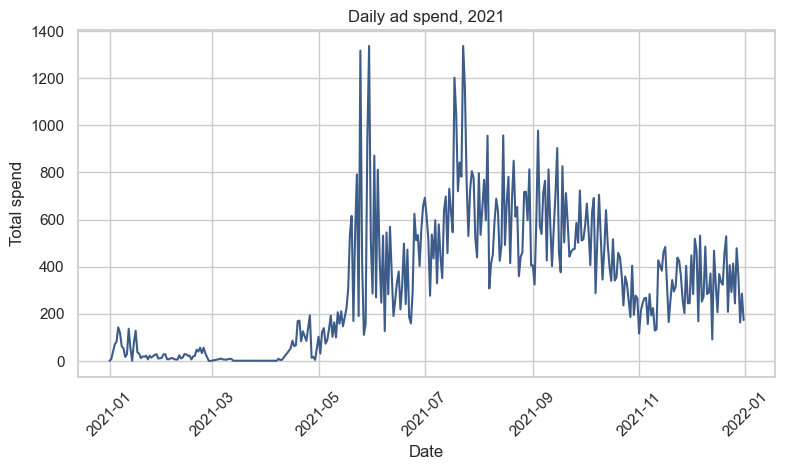

In [7]:
plt.figure(figsize=(9, 4.5))
plt.plot(daily_stats_2021['ad_date'], daily_stats_2021['total_spend'], linestyle='solid', color=NAVY)
plt.xticks(rotation=45)
plt.title('Daily ad spend, 2021')
plt.xlabel('Date')
plt.ylabel('Total spend')
plt.show()

Spend was close to zero until April 2021, rose sharply in May, peaked in the summer months and then gradually decreased through the last quarter.

## 4. ROMI over time

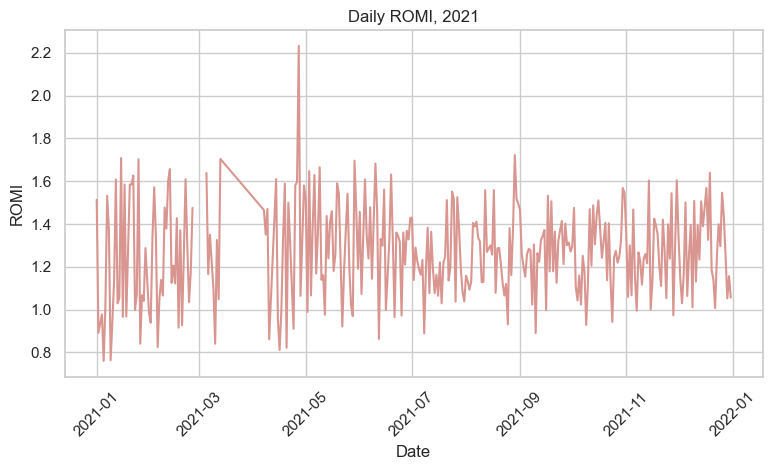

In [8]:
plt.figure(figsize=(9, 4.5))
plt.plot(daily_stats_2021['ad_date'], daily_stats_2021['romi'], linestyle='solid', color=ROSE)
plt.xticks(rotation=45)
plt.title('Daily ROMI, 2021')
plt.xlabel('Date')
plt.ylabel('ROMI')
plt.show()

ROMI did **not** follow the spend pattern. It fluctuates mostly between 0.8 and 1.7 all year, with no visible drop when spend increased several times over. The single spike above 2.0 (end of April) happened on a day with very low spend, so it does not reflect a real efficiency gain. Short gaps in the line are days with no data.

## 5. Campaign comparison

Total spend and value per campaign, with ROMI and each campaign's share of the total budget.

In [9]:
campaign_stats = df.groupby('campaign_name', as_index=False).agg(
    total_spend=('total_spend', 'sum'),
    total_value=('total_value', 'sum')
)
campaign_stats['romi'] = campaign_stats['total_value'] / campaign_stats['total_spend']
campaign_stats['spend_share_%'] = campaign_stats['total_spend'] / campaign_stats['total_spend'].sum() * 100
campaign_stats.sort_values('romi', ascending=False).round(2)

,campaign_name,total_spend,total_value,romi,spend_share_%
9,Trendy,1992.31,3798.90,1.91,1.02
8,Promos,4993.84,8793.77,1.76,2.55
7,New items,2936.97,3742.05,1.27,1.50
6,Lookalike,63631.09,80234.70,1.26,32.50
0,Brand,539.92,670.15,1.24,0.28
4,Expansion,67212.82,83288.66,1.24,34.33
5,Hobbies,11326.97,13974.63,1.23,5.79
2,Discounts,2856.39,3516.27,1.23,1.46
10,Wholesale,14181.71,17421.33,1.23,7.24
3,Electronics,23920.42,29169.38,1.22,12.22


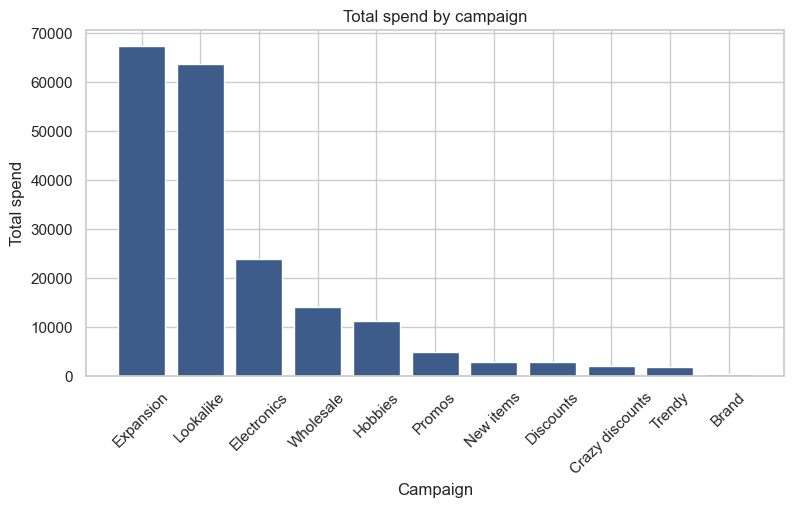

In [10]:
campaign_stats_sorted = campaign_stats.sort_values('total_spend', ascending=False)
plt.figure(figsize=(9, 4.5))
plt.bar(campaign_stats_sorted['campaign_name'], campaign_stats_sorted['total_spend'], color=NAVY)
plt.xticks(rotation=45)
plt.title('Total spend by campaign')
plt.xlabel('Campaign')
plt.ylabel('Total spend')
plt.show()

The budget is heavily concentrated: *Expansion* (34%) and *Lookalike* (33%) take about two thirds of all spend, followed by *Electronics* (12%). The remaining eight campaigns share the last 21%.

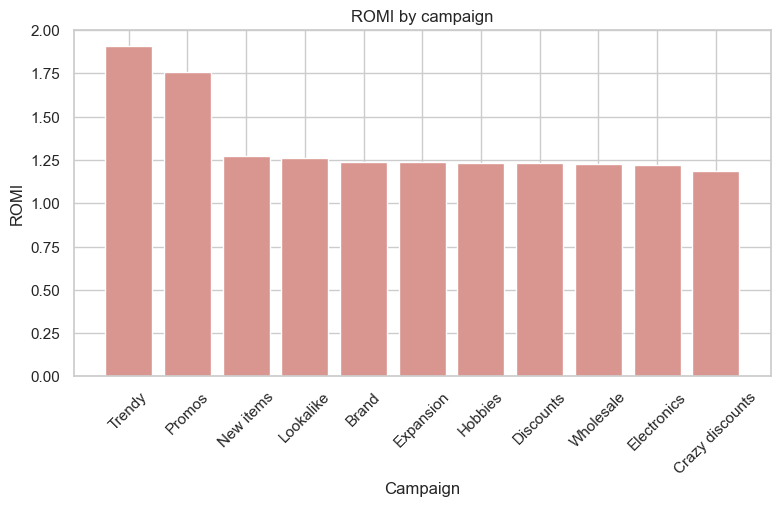

In [11]:
campaign_stats_sorted = campaign_stats.sort_values('romi', ascending=False)
plt.figure(figsize=(9, 4.5))
plt.bar(campaign_stats_sorted['campaign_name'], campaign_stats_sorted['romi'], color=ROSE)
plt.xticks(rotation=45)
plt.title('ROMI by campaign')
plt.xlabel('Campaign')
plt.ylabel('ROMI')
plt.show()

Efficiency is much more even than the budget. Nine of the eleven campaigns return between 1.19 and 1.27 per unit spent, while *Trendy* (1.91) and *Promos* (1.76) stand clearly apart. Together they receive only 3.6% of spend, which makes them the best candidates for a bigger budget. Every campaign is above break-even; even the weakest, *Crazy discounts*, returns 1.19.

## 6. Distribution of ROMI

Averages can hide a lot of variation, so the next step is to look at how daily ROMI is spread, overall and by campaign.

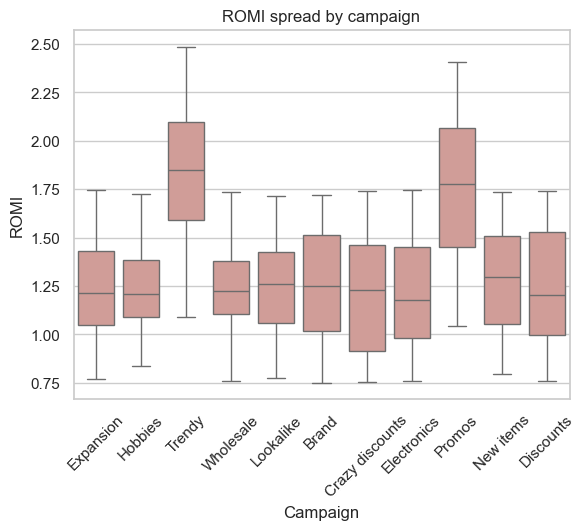

In [12]:
sns.boxplot(df, x='campaign_name', y='romi', color=ROSE)
plt.xticks(rotation=45)
plt.title('ROMI spread by campaign')
plt.xlabel('Campaign')
plt.ylabel('ROMI')
plt.show()

*Trendy* (median about 1.85) and *Promos* (about 1.77) sit well above the others, and the lowest values for *Trendy* stay around 1.1, so it was profitable on almost every day. The other campaigns have a median of about 1.2 to 1.3 and all drop to roughly 0.75 to 0.85 on their weakest days. A day below break-even is normal for them.

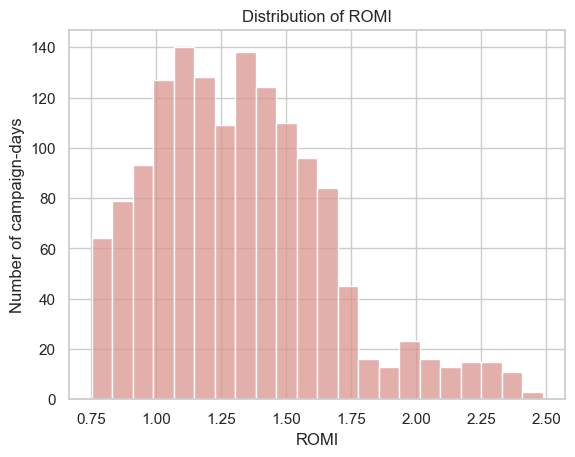

In [13]:
sns.histplot(df, x="romi", color=ROSE)
plt.title('Distribution of ROMI')
plt.xlabel('ROMI')
plt.ylabel('Number of campaign-days')
plt.show()

Most campaign-days fall between about 0.75 and 1.75. A smaller group of strong days between 1.75 and 2.5 forms a tail on the right, and it comes mostly from *Trendy* and *Promos*.

## 7. Correlations

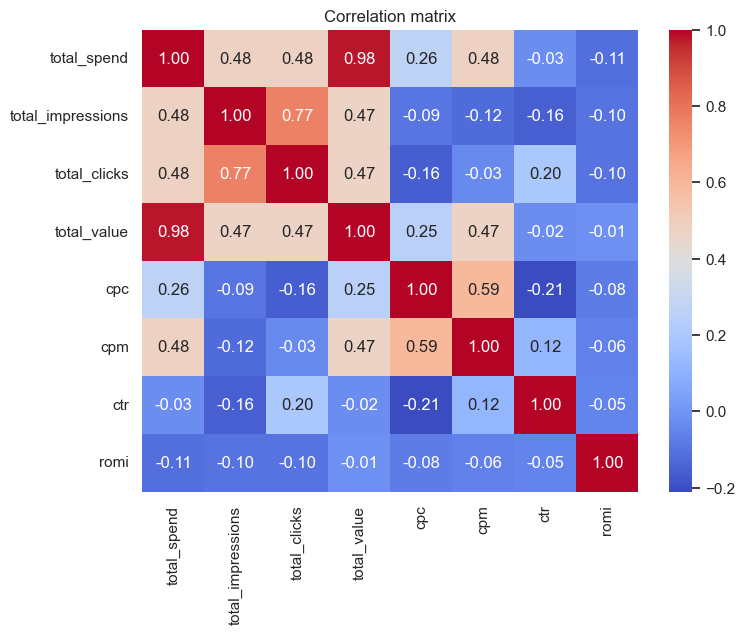

In [14]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix')
plt.show()

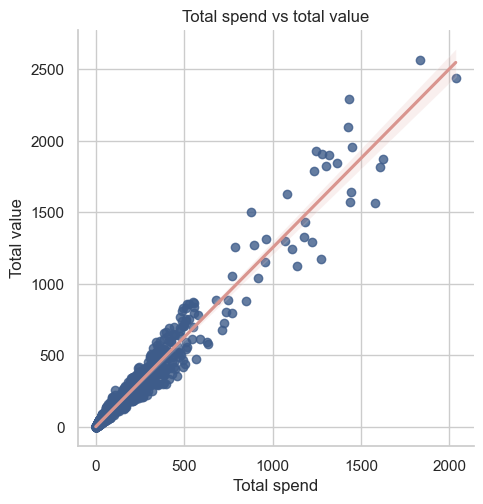

In [15]:
sns.lmplot(data=df, x='total_spend', y='total_value', scatter_kws={"color": NAVY}, line_kws={"color": ROSE})
plt.title('Total spend vs total value')
plt.xlabel('Total spend')
plt.ylabel('Total value')
plt.show()

- **Spend and value are almost perfectly correlated** (0.98), so returns scale with budget.
- **ROMI is nearly independent of everything else** (all values between -0.16 and 0). More spend did not make campaigns less efficient, and cheaper clicks or a higher CTR did not by themselves lead to a better return.
- Impressions and clicks are strongly related to each other (0.77) but only moderately to spend (about 0.48).
- Differences in efficiency therefore come from the campaigns themselves (audience, offer, creative), not from volume or traffic metrics.

## 8. Conclusions and recommendations

1. **Test moving more budget to *Trendy* and *Promos*.** They return about 50% more per unit than the rest and were profitable on almost every day, but receive only 3.6% of spend. A step-by-step increase, for example doubling their budget while checking ROMI weekly, is a low-risk way to see whether the advantage holds at a larger scale.
2. **Review *Expansion* and *Lookalike*.** They carry two thirds of the budget at an average ROMI of about 1.25, so even a small improvement there (creatives, audiences) would matter more than gains in small campaigns.
3. **Do not expect higher spend to improve efficiency.** Spend and ROMI are uncorrelated: scaling a campaign multiplies the efficiency it already has.
4. **Judge ROMI over weeks, not days.** Daily values swing widely (about 0.75 to 2.5) even for stable campaigns, so weekly averages are a more reliable basis for decisions.

### Limitations

- ROMI here is a ratio of value to spend. The dataset does not state the currency or whether `total_value` means revenue or margin, so profitability conclusions assume value is comparable to spend.
- The best campaigns have small budgets, so their results may not hold at a larger scale. That is why the first recommendation is a test.
- There is no data on audiences, creatives or seasonality. Natural next steps are a month-by-month comparison per campaign and a check of whether campaign efficiency changes as a campaign gets older.